# Laboratorio 1 – Exploración, preparación y regresión lineal

**Curso:** ISIS-2611 – Aprendizaje de Máquina  

**Caso:** AlpesPlanck  

**Autores:** Lucas Valbuena 202311538 y Juan Goyeneche 202320863

**Semestre:** 2026-02


## 0. Configuración del entorno


### 0.1 Importación de librerías 

*Se importaron las librerías necesarias para manipulación, visualización y modelado.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### 0.2 Configuración global de consideraciones


In [2]:
random_state = 42
np.random.seed(random_state)

test_size = 0.25

### 0.3 Carga de los datos


*Se cargaron los datos de entrenamiento desde la carpeta `data/`. El archivo de test se cargará posteriormente, cuando se haya seleccionado el mejor modelo.*

In [3]:
datos_entrenamiento = pd.read_csv("data/Datos Lab 1.csv")
data = datos_entrenamiento.copy()

## 1. Entendimiento del negocio y de los datos


### 1.1 Descripción del caso y objetivo del modelo


*El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas en su estación de Jena, Alemania. El objetivo del laboratorio fue explorar estos datos y preparar un modelo de regresión lineal para predecir la temperatura máxima del día siguiente, de manera que la información pudiera apoyar la prevención de riesgos como incendios forestales y los efectos asociados con El Niño y La Niña.*

### 1.2 Revisión del diccionario de datos


In [4]:
diccionario_datos = pd.read_excel("data/Diccionario de datos.xlsx")
display(diccionario_datos)

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


*Mediante la función `display` se mostró el diccionario de variables. Luego, se procedió a categorizar las variables según sus tipos: categóricas, numéricas continuas y numéricas discretas.*

In [5]:
variables_categoricas = diccionario_datos.loc[
    diccionario_datos["tipo"] == "texto", "variable"
].tolist()

variables_numericas = diccionario_datos.loc[
    diccionario_datos["tipo"] == "numérico", "variable"
].tolist()
variables_numericas_discretas = [
    "registros_del_dia",
    "anio",
    "dia_del_anio",
]
variables_numericas_continuas = [
    variable
    for variable in variables_numericas
    if variable not in variables_numericas_discretas
]

print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Variables numéricas continuas: {len(variables_numericas_continuas)}")
print(f"Variables numéricas discretas: {len(variables_numericas_discretas)}")

Variables categóricas: 4
Variables numéricas continuas: 20
Variables numéricas discretas: 3


### 1.3 Definición de la variable objetivo (temperatura máxima del día)


*Se definió explícitamente la temperatura máxima del día como variable objetivo.*

In [6]:
variable_objetivo = "temp_max_manana"

## 2. Exploración de los datos 


### 2.1 Estructura general del dataset


*Se revisaron las dimensiones, los tipos, las primeras filas y la información general del dataset.*

In [7]:
print("Dimensiones del dataset:")
print(f"Filas: {datos_entrenamiento.shape[0]}, Columnas: {datos_entrenamiento.shape[1]}")

print("\nPrimeras cinco filas:")
display(datos_entrenamiento.head())

Dimensiones del dataset:
Filas: 2576, Columnas: 27

Primeras cinco filas:


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


*No se incluyeron nuevamente las funciones `dtypes` e `info` porque los tipos de variables y la información general ya fueron mostrados en el diccionario de datos. De esta manera, se evitó repetir información y se conservaron en esta sección únicamente las revisiones adicionales de estructura.*

### 2.2 Estadísticas descriptivas


*Se resumieron las variables con estadísticas descriptivas apropiadas.*

In [8]:
print("Estadísticas descriptivas:")
display(datos_entrenamiento.describe(include="all").T)

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2009-01-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


*Los valores `25%`, `50%` y `75%` corresponden a los cuartiles de las variables numéricas. El primer cuartil (`25%`) indica que aproximadamente el 25% de los datos tiene un valor menor o igual a ese punto. El segundo cuartil (`50%`) es la mediana, es decir, divide los datos en dos partes iguales. El tercer cuartil (`75%`) indica que aproximadamente el 75% de los datos tiene un valor menor o igual a ese punto. En las variables categóricas, `freq` representa cuántas veces aparece la categoría más frecuente, no un porcentaje.*

## 3. Calidad de los datos

| Dimensión | Pregunta que responde |
|---|---|
| Completitud | ¿Faltan datos? |
| Unicidad | ¿Hay registros duplicados? |
| Consistencia | ¿Los valores del mismo concepto están representados de forma uniforme? |
| Validez | ¿Los valores están dentro del rango permitido y tienen sentido en el contexto? |

### 3.1 Completitud

*Se revisó la presencia de datos faltantes en las variables del conjunto.*

In [9]:
((data.isnull().sum() / data.shape[0])).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
mes                  0.034161
estacion_anio        0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
presion_desv         0.031056
humedad_min          0.031056
viento_norte         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
humedad_media        0.028727
presion_min          0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
viento_este          0.024845
presion_max          0.024845
humedad_desv         0.023680
dtype: float64

*Se observó que todas las variables del conjunto de datos presentan valores faltantes. Para cada variable se informó su nombre, el número de filas con valores nulos y los primeros índices correspondientes, sin imprimir tablas completas.*

In [10]:
for variable in data.columns:
    nulos = data[data[variable].isna()].copy()
    indices = data.index[data[variable].isna()]

    print(f"\n{'=' * 70}")
    print(f"Variable: {variable}")
    print(f"Filas con {variable} nula: {nulos.shape[0]}")
    print(f"Primeros índices de los registros nulos: {indices[:10].tolist()}")


Variable: fecha
Filas con fecha nula: 72
Primeros índices de los registros nulos: [85, 96, 224, 237, 266, 323, 403, 475, 537, 660]

Variable: presion_media
Filas con presion_media nula: 75
Primeros índices de los registros nulos: [72, 165, 167, 174, 195, 201, 217, 230, 256, 308]

Variable: presion_min
Filas con presion_min nula: 74
Primeros índices de los registros nulos: [4, 5, 7, 81, 133, 143, 185, 233, 235, 260]

Variable: presion_max
Filas con presion_max nula: 64
Primeros índices de los registros nulos: [10, 102, 112, 115, 137, 149, 216, 280, 336, 363]

Variable: presion_desv
Filas con presion_desv nula: 80
Primeros índices de los registros nulos: [23, 43, 45, 46, 66, 101, 116, 139, 178, 181]

Variable: humedad_media
Filas con humedad_media nula: 74
Primeros índices de los registros nulos: [31, 80, 116, 169, 206, 235, 279, 284, 298, 305]

Variable: humedad_min
Filas con humedad_min nula: 80
Primeros índices de los registros nulos: [26, 55, 56, 248, 264, 337, 403, 421, 427, 481]



*Como conclusión, se evidenció que todas las variables presentan valores nulos, por lo que la completitud del conjunto de datos está afectada. En las variables predictoras no se eliminaron las filas: los valores faltantes se tratarán posteriormente mediante imputación, utilizando la media para las variables numéricas y la categoría más frecuente para las variables categóricas.*

*La variable objetivo `temp_max_manana` es la excepción. Un registro sin temperatura no aporta la respuesta que el modelo debe aprender, y esa respuesta no se puede imputar sin inventarla, lo que sesgaría tanto el entrenamiento como las métricas de evaluación. Por eso esos registros se eliminarán en la sección 4 (Preparación de los datos), junto con las demás operaciones que cambian el número de filas.*

In [11]:
nulos_objetivo = data[variable_objetivo].isna().sum()

print(f"Registros sin {variable_objetivo}: {nulos_objetivo} de {data.shape[0]} "
      f"({100 * nulos_objetivo / data.shape[0]:.2f} %)")

Registros sin temp_max_manana: 95 de 2576 (3.69 %)


### 3.2 Unicidad

In [12]:
int(data.duplicated(keep=False).sum())

8

*Se revisó la existencia de registros duplicados en el conjunto.*
*Se identificaron 8 filas idénticas, es decir, filas en las que todas las columnas tienen los mismos valores que en otra fila. También se consideraron los duplicados lógicos: registros que no son idénticos, pero que podrían representar la misma observación según la lógica del negocio. En este caso, como cada fila corresponde a un día, se revisaron las fechas que aparecen más de una vez como posibles duplicados lógicos.*

In [13]:
# fechas duplicadas
dup_counts = (data["fecha"].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for fecha, n in dup_counts.items():
    print(f"Fecha={fecha} -> {n} apariciones")

Fecha=2009-01-22 -> 2 apariciones
Fecha=2009-03-05 -> 2 apariciones
Fecha=2015-05-11 -> 2 apariciones
Fecha=2015-02-03 -> 2 apariciones
Fecha=2015-01-07 -> 2 apariciones
Fecha=2013-05-29 -> 2 apariciones
Fecha=2013-04-20 -> 2 apariciones
Fecha=2013-02-08 -> 2 apariciones
Fecha=2013-01-02 -> 2 apariciones
Fecha=2012-11-22 -> 2 apariciones
Fecha=2012-11-13 -> 2 apariciones
Fecha=2012-10-06 -> 2 apariciones
Fecha=2012-10-04 -> 2 apariciones
Fecha=2010-10-25 -> 2 apariciones
Fecha=2010-08-14 -> 2 apariciones
Fecha=2009-12-08 -> 2 apariciones
Fecha=2009-05-02 -> 2 apariciones
Fecha=2015-12-07 -> 2 apariciones


In [14]:
# Detalle de los registros con fechas repetidas (se ignoran las fechas nulas)
data_con_fecha = data[data["fecha"].notna()]
dup_table = (
    data_con_fecha[data_con_fecha["fecha"].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data_con_fecha.groupby("fecha")["fecha"].transform("size"))
    .sort_values(["repeticiones", "fecha"], ascending=[False, True])
)

# Mostrar tabla
display(dup_table)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,2
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,2
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000,2
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000,2
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2


*Se verificó que las filas con la misma fecha tienen los mismos valores en sus demás columnas, por lo que sí corresponden a duplicados lógicos, ya que `fecha` actúa como identificador (id) de cada registro.*

### 3.3 Consistencia

- **Inconsistencia de formato en texto**: `'NO'` vs. `'no'` vs. `'No'` para la misma categoría.
- **Inconsistencia entre columnas**: dos columnas que deberían ser equivalentes (e.g., peso en kg y peso en libras) tienen valores contradictorios.
- **Inconsistencia entre filas**: el mismo campo tiene formatos distintos en registros diferentes (e.g., fechas escritas como `'2023-01-15'` y `'15/01/2023'`).

In [15]:
data['mes'].value_counts()

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 61, dtype: int64

Inconsistencia en la variable mes: aunque un año solo tiene doce meses, la columna mes presenta 61 valores únicos. Esto ocurre porque el mismo mes está registrado con distintos formatos: en español y en inglés ('Enero' vs. 'January'), y con distintas combinaciones de mayúsculas y minúsculas ('January' vs. 'JANUARY').

In [16]:
data['anio'].value_counts()

anio
2010.0    358
2009.0    356
2012.0    356
2013.0    356
2011.0    355
2014.0    355
2015.0    354
Name: count, dtype: int64

### 3.4 Validez

*Se revisó que los valores estuvieran dentro del rango permitido y fueran pertinentes para el contexto.*

In [17]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Al analizar `data.describe()` se identificaron varios valores fuera de rango físicamente posible, lo que evidencia problemas de validez:

- **`presion_media`**: el máximo (9939.92) es incompatible con `presion_min` y `presion_max`, cuyos máximos rondan 1012–1014 hPa. Probablemente es un error de captura (falta un punto decimal, p. ej. 993.99 registrado como 9939.92).
- **`humedad_min`**: el máximo (103.31 %) supera el límite físico de 100 %.
- **`rafaga_min`**: el mínimo es -9999, un valor centinela típico de dato faltante o error de sensor, no una ráfaga real.
- **`rafaga_desv`** y **`viento_norte`**: presentan valores extremos (máximo 3471.03 y mínimo -1250.46, respectivamente) muy alejados del rango intercuartílico, lo que sugiere outliers(valores atipicos) o errores de medición.


- **`temp_max_manana`** (variable objetivo): el máximo es 63.05 °C, seguido de 61.41 °C, 44.98 °C y 44.85 °C. Son valores físicamente imposibles para Jena: durante el periodo que cubren los datos (2009–2015), el récord nacional de temperatura de Alemania era de 40.3 °C, medido en Kitzingen el 5 de julio y el 7 de agosto de 2015 (Deutscher Wetterdienst, 2015). Incluso el cuarto valor más alto supera ese récord en más de 4 °C. Las dos filas con los valores extremos presentan además una inconsistencia entre columnas: la fila con fecha `2012-10-04` aparece registrada con `mes = "febrero"`, y la de fecha `2013-04-20` con `mes = "JANUARY"`, de modo que `mes` contradice a `fecha`. Este problema es especialmente grave porque afecta a la variable que el modelo debe aprender a predecir: un valor imposible en la variable objetivo no es ruido en una entrada, sino una etiqueta errónea.

En contraste, variables como `direccion_viento` (0°–359.8°), `anio` (2009–2015) y `dia_del_anio` (1–366) se mantienen dentro de rangos válidos y coherentes con el contexto. El mínimo de `temp_max_manana` (-15.23 °C) también es plausible para un invierno en Alemania central; el problema de validez de esta variable se presenta únicamente por el extremo superior.

## 4. Preparación de los datos

### 4.1 Decisiones de limpieza ( transformaciones que aplicaremos)

| Variable | Transformación | Razón |
|----------|-----------------|-------|
| Numéricas | Imputación por media + `StandardScaler` | Valores nulos en todas las variables numéricas (sección 3.1, Completitud) |
| Categóricas | IImputación por moda + `OneHotEncoder` | Valores nulos en todas las variables categóricas (sección 3.1, Completitud) |
| Todo el dataset | Eliminación de las filas sin valor en la variable objetivo `temp_max_manana` | La variable objetivo no se puede imputar: rellenarla equivaldría a inventar la respuesta que el modelo debe aprender (sección 3.1, Completitud) |
| Todo el dataset | Eliminación de las filas con `temp_max_manana` superior a 42 °C | Valores físicamente imposibles para Jena (63.05 °C y 61.41 °C, entre otros), muy por encima del récord nacional alemán de 40.3 °C vigente durante 2009–2015; una etiqueta errónea no se puede corregir, solo descartar (sección 3.4, Validez) |
| Todo el dataset | Eliminación de filas duplicadas idénticas | Se identificaron 8 filas exactamente iguales (sección 3.2, Unicidad) |
| Todo el dataset (agrupado por `fecha`) | Eliminación de duplicados lógicos, conservando un único registro por `fecha` | `fecha` actúa como identificador de cada día; las filas repetidas corresponden a la misma observación (sección 3.2, Unicidad) |
| `mes` | Normalización a minúsculas y en español | El mismo mes aparecía en 61 formatos distintos por diferencias de idioma (español/inglés) y capitalización (sección 3.3, Consistencia) |
| `presion_media` | Clipping al rango físico válido (~950–1014 hPa, según `presion_min`/`presion_max`) | El máximo (9939.92) es incompatible con `presion_min` y `presion_max` (~1012–1014 hPa) (sección 3.4, Validez) |
| `humedad_min` | Clipping al rango [0, 100] % | El máximo (103.31 %) supera el límite físico de humedad (sección 3.4, Validez) |
| `rafaga_min` | Reemplazo del valor -9999 por faltante (NaN) | -9999 es un valor centinela de error de sensor, no una ráfaga real (sección 3.4, Validez) |
| `rafaga_desv`, `viento_norte` | Normalización por z-score con clipping de outliers (p. ej. ±3 desviaciones estándar) | Valores muy alejados del rango intercuartílico (máximo 3471.03 y mínimo -1250.46) (sección 3.4, Validez) |


*Se eliminaron los duplicados detectados en la sección 3.2 (Unicidad): primero las 8 filas exactamente iguales, y luego los duplicados lógicos, conservando un único registro por `fecha` (las filas sin `fecha` no se pudieron evaluar como lógicamente duplicadas, por lo que se conservaron). Esta limpieza se aplicó directamente sobre `data`, antes de dividir en entrenamiento y prueba, ya que cambia el número de filas y no puede formar parte del pipeline de scikit-learn.*

In [18]:
data = data.drop_duplicates(keep="first")

data_con_fecha = data[data["fecha"].notna()].drop_duplicates(subset="fecha", keep="first")
data_sin_fecha = data[data["fecha"].isna()]
data = pd.concat([data_con_fecha, data_sin_fecha]).sort_index()


*Se descartaron los registros sin valor en la variable objetivo `temp_max_manana`, identificados en la sección 3.1 (Completitud). A diferencia de las variables predictoras, la variable objetivo no se puede imputar: rellenarla con la media equivaldría a inventar la respuesta que el modelo debe aprender, lo que sesgaría el entrenamiento y volvería poco confiables las métricas. Al igual que la eliminación de duplicados, esta operación cambia el número de filas, por lo que se aplicó directamente sobre `data` y no dentro del pipeline de scikit-learn.*

In [19]:
filas_antes = data.shape[0]
data = data[data[variable_objetivo].notna()].copy()

print(f"Registros descartados por no tener {variable_objetivo}: {filas_antes - data.shape[0]}")
print(f"Registros disponibles para el modelamiento: {data.shape[0]}")

Registros descartados por no tener temp_max_manana: 95
Registros disponibles para el modelamiento: 2463


*Se descartaron también los registros cuya `temp_max_manana` supera los 42 °C, identificados en la sección 3.4 (Validez). Se eligió ese umbral como cota física conservadora: el récord nacional de temperatura de Alemania durante el periodo que cubren los datos era de 40.3 °C (Deutscher Wetterdienst, 2015), de modo que 42 °C deja un margen amplio y solo elimina registros claramente imposibles. A diferencia de los problemas de validez en las variables predictoras —que se corrigen mediante recorte dentro del pipeline—, aquí no es posible corregir el valor: un dato imposible en la variable objetivo es una **etiqueta errónea**, y entrenar con ella enseñaría al modelo una relación que no existe. La única opción válida es descartar esas filas, y como la operación cambia el número de registros se aplica directamente sobre `data`.*

In [20]:
TOPE_FISICO_TEMPERATURA = 42  # °C — cota conservadora sobre el récord nacional alemán (40.3 °C, DWD 2015)

filas_antes = data.shape[0]
registros_invalidos = data.loc[data[variable_objetivo] > TOPE_FISICO_TEMPERATURA,
                               ["fecha", "mes", "estacion_anio", variable_objetivo]]

print(f"Registros con {variable_objetivo} > {TOPE_FISICO_TEMPERATURA} °C:")
display(registros_invalidos.sort_values(variable_objetivo, ascending=False))

data = data[data[variable_objetivo] <= TOPE_FISICO_TEMPERATURA].copy()

print(f"Registros descartados por temperatura imposible: {filas_antes - data.shape[0]}")
print(f"Registros disponibles para el modelamiento: {data.shape[0]}")

Registros con temp_max_manana > 42 °C:


,fecha,mes,estacion_anio,temp_max_manana
1372,2012-10-04,febrero,otono,63.050
1570,2013-04-20,JANUARY,primavera,61.412
2197,2015-01-07,May,verano,44.978
1412,2012-11-13,abril,otono,44.852


Registros descartados por temperatura imposible: 4
Registros disponibles para el modelamiento: 2459


*Se construyó el transformador para las variables numéricas: primero se imputan los valores faltantes con la media de cada columna (sección 3.1, Completitud) y luego se estandarizan con `StandardScaler`, para que todas las variables numéricas queden en la misma escala antes de entrenar el modelo.*

In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)


*Se construyó el transformador para las variables categóricas: primero se imputan los valores faltantes con la categoría más frecuente de cada columna (sección 3.1, Completitud) y luego se codifican con `OneHotEncoder`, para convertirlas en variables numéricas que el modelo de regresión pueda utilizar.*

In [22]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
    ]
)


*Se definió una función de normalización para la variable `mes`: se pasa el texto a minúsculas y se traducen los nombres en inglés (completos y abreviados) a español, para unificar los 61 formatos distintos detectados en la sección 3.3 (Consistencia) en las 12 categorías reales de un año. La función se envolvió en un `FunctionTransformer` para poder integrarla más adelante en el pipeline de preparación.*

In [23]:
def normalizar_mes(df):
    df = df.copy()
    mapa_meses = {
        "january": "enero", "jan": "enero",
        "february": "febrero", "feb": "febrero",
        "march": "marzo", "mar": "marzo",
        "april": "abril", "apr": "abril",
        "may": "mayo",
        "june": "junio", "jun": "junio",
        "july": "julio", "jul": "julio",
        "august": "agosto", "aug": "agosto",
        "september": "septiembre", "sep": "septiembre", "sept": "septiembre",
        "october": "octubre", "oct": "octubre",
        "november": "noviembre", "nov": "noviembre",
        "december": "diciembre", "dec": "diciembre",
    }
    df["mes"] = df["mes"].str.lower().replace(mapa_meses)
    return df

normalizar_mes_tr = FunctionTransformer(normalizar_mes)


*Se definió `corregir_validez`, una función que aplica las correcciones identificadas en la sección 3.4 (Validez): recorta `presion_media` al rango físico válido de `presion_min`/`presion_max`, recorta `humedad_min` a [0, 100] %, reemplaza el valor centinela -9999 de `rafaga_min` por faltante (NaN), aplica un recorte por z-score (±3 desviaciones estándar) a `rafaga_desv` y `viento_norte`, y recorta `registros_del_dia` al máximo esperado de 144 mediciones por día. La función se envolvió en un `FunctionTransformer` para integrarla al pipeline de preparación.*

In [24]:
def corregir_validez(df):
    df = df.copy()

    df["presion_media"] = df["presion_media"].clip(
        lower=df["presion_min"].min(), upper=df["presion_max"].max()
    )

    df["humedad_min"] = df["humedad_min"].clip(lower=0, upper=100)

    df["rafaga_min"] = df["rafaga_min"].replace(-9999, np.nan)

    for columna in ["rafaga_desv", "viento_norte"]:
        media = df[columna].mean()
        desviacion = df[columna].std()
        df[columna] = df[columna].clip(
            lower=media - 3 * desviacion, upper=media + 3 * desviacion
        )

    df["registros_del_dia"] = df["registros_del_dia"].clip(upper=144)

    return df

corregir_validez_tr = FunctionTransformer(corregir_validez)


*Se definieron las listas de columnas numéricas y categóricas que recibirá el `ColumnTransformer` (excluyendo la variable objetivo `temp_max_manana` y `fecha`, que solo actúa como identificador de cada registro), y se creó `dropper`, un `FunctionTransformer` que elimina la columna `fecha` antes del preprocesamiento, ya que no aporta información predictiva.*

In [25]:
numeric_features = [v for v in variables_numericas if v != variable_objetivo]
categorical_features = [v for v in variables_categoricas if v != "fecha"]

def eliminar_fecha(df):
    return df.drop(columns=["fecha"])

dropper = FunctionTransformer(eliminar_fecha)


*Se ensambló el `ColumnTransformer` que aplica `numeric_transformer` a las variables numéricas y `categorical_transformer` a las variables categóricas, uniendo en un solo objeto todo el preprocesamiento definido anteriormente.*

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


*Se construyó el pipeline completo de preparación (`pipeline_regresion`): elimina la columna `fecha` (`dropper`), normaliza los formatos de `mes` (`normalizar_mes_tr`), corrige los valores inválidos detectados en la sección 3.4 (`corregir_validez_tr`) y finalmente aplica el preprocesamiento numérico y categórico (`preprocessor`).*

In [27]:
pipeline_regresion = Pipeline(steps=[
    ("dropper", dropper),
    ("normalizar_mes", normalizar_mes_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor),
])


*Se configuró scikit-learn para mostrar los pipelines como un diagrama visual en lugar de texto, facilitando la revisión de su estructura.*

In [28]:
from sklearn import set_config
set_config(display="diagram")


*Se visualizó el pipeline de preparación (`pipeline_regresion`) como diagrama para verificar que sus pasos quedaron correctamente encadenados.*

In [29]:
pipeline_regresion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('normalizar_mes', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...t 0x11bd2efb0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDi

## 5. Modelamiento – Regresión lineal

*Se construyeron y compararon dos pipelines de regresión lineal.*

### 5.1 Particion de los datos

*Una vez realizadas las tareas previas de limpieza y definido el pipeline de preparación, se separaron los datos en dos conjuntos: entrenamiento (**train**), utilizado para entrenar el modelo de regresión lineal, y prueba (**test**), destinado a evaluar su desempeño sobre datos no vistos. En esta etapa también se definieron las variables del modelo: la variable objetivo o dependiente es `temp_max_manana` y el resto de las variables se consideraron inicialmente como variables predictoras.*

*Se separaron las variables: `X` contiene todas las variables independientes que sirven como insumo para predecir la variable objetivo, y `y` contiene la variable objetivo.*

In [30]:
X = data.drop(columns=[variable_objetivo])
y = data[variable_objetivo]

*A continuación se verificó que la separación de las variables se hubiera realizado correctamente.*

In [31]:
X

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.778600,...,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.419500,...,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.250900,...,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.720400,...,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.800300,...,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2553,2015-12-29,1002.1544,1000.83,1005.33,1.2520,95.091000,79.400000,99.5,5.3604,0.866100,...,0.7173,-0.5544,-0.0871,188.9267,144.0,2015.0,363.0,invierno,December,S
2554,2015-12-30,1002.9883,997.51,1005.73,2.5524,84.473700,NaN,99.4,12.9567,2.127400,...,2.0483,-2.0540,-0.1130,183.1497,144.0,2015.0,364.0,invierno,diciembre,SOUTH
2555,2015-12-31,996.9224,995.01,999.20,1.4003,0.726064,0.495600,97.4,17.6803,3.113100,...,1.9769,-3.0401,0.1673,176.8493,144.0,NaN,365.0,invierno,NaN,S
2558,2014-12-05,991.3662,989.90,992.95,0.9265,97.286100,94.700000,99.0,1.2766,2.373840,...,-15.8000,-0.2577,-0.0599,193.0743,144.0,2014.0,339.0,verano,September,S


In [32]:
y

0       -2.120
1       -0.820
2       -0.630
3       -1.440
4      -10.880
         ...  
2553     5.650
2554     2.920
2555     2.720
2558    40.118
2569     2.870
Name: temp_max_manana, Length: 2459, dtype: float64

*Confirmada la separación, se dividió el conjunto en entrenamiento (**train**) y prueba (**test**). Esta decisión depende del modelador; en este caso se utilizó el 75 % de los datos para entrenar el modelo y el 25 % restante para evaluarlo (`test_size = 0.25`, definido en la sección 0.2). Esta proporción permite contar con suficiente información para el aprendizaje y, al mismo tiempo, reservar un conjunto de datos no visto para medir el rendimiento en nuevos ejemplos. La partición se realizó con `train_test_split()`, que recibe las variables explicativas `X`, la variable objetivo `y`, la proporción del conjunto de prueba y el parámetro `random_state`, que garantiza que la partición sea reproducible y que los resultados puedan compararse entre ejecuciones.*

In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=test_size, random_state=random_state)

*Adicionalmente, se revisó el tamaño de cada conjunto.*

In [34]:
X_train.shape, y_train.shape

((1844, 26), (1844,))

In [35]:
X_test.shape, y_test.shape

((615, 26), (615,))

### 5.2 Modelo 2: pipeline con estrategia de preparación B

*Se definió el segundo pipeline y su estrategia de preparación B. Mientras la estrategia A utiliza **todas** las variables disponibles (22 numéricas y 3 categóricas, que tras el `OneHotEncoder` se convierten en 95 columnas), la estrategia B parte de un conjunto reducido y deliberado de variables y añade dos transformaciones adicionales de preparación. El resto del preprocesamiento se mantiene igual que en A —imputación por media y `StandardScaler`— de modo que la comparación sea justa.*

**Variables seleccionadas**

| Grupo | Variables | Justificación |
|---|---|---|
| Humedad | `humedad_media`, `humedad_min`, `humedad_max`, `humedad_desv` | Junto con la temperatura, la humedad cerca de la superficie es el predictor más influyente reportado en la literatura de predicción de calor extremo con aprendizaje de máquina (Ashford et al., 2026) |
| Presión | `presion_media`, `presion_min`, `presion_max`, `presion_desv` | Los sistemas de alta presión están asociados a cielos despejados y mayor insolación; se conservan porque su exclusión empeoró el RMSE |
| Estacionalidad | `dia_sin`, `dia_cos` (derivadas de `dia_del_anio`) | Codificación cíclica del día del año (ver más abajo) |
| Viento zonal | `viento_este` | Componente este-oeste del viento; la advección zonal en superficie está asociada a los episodios cálidos invernales en Europa (Holmberg et al., 2023) |

*Se descartaron las tres variables categóricas (`estacion_anio`, `mes`, `sector_viento`), el resto de variables de viento y ráfaga, `registros_del_dia` y `direccion_viento`. Las categóricas presentan decenas de variantes de escritura sin normalizar (sección 3.3) que generan columnas binarias con muy pocos registros; las de ráfaga y viento contienen valores extremos que `corregir_validez` no recorta de forma consistente entre entrenamiento y prueba.*

**Nota — por qué se consideró `anio` y por qué se descartó**

*Una variable candidata natural era `anio`. La idea de partida es razonable: si la temperatura sube año tras año por el calentamiento global, el año de observación aportaría información sobre el nivel base de temperatura. El Copernicus Climate Change Service documenta esa tendencia así:*

> "Europe is the fastest-warming continent, with temperatures rising by approximately 0.56 °C per decade since the mid-1990s, more than double the global average."
>
> — Copernicus Climate Change Service (C3S/ECMWF), *European State of the Climate 2025*.

*Sin embargo, al analizar los datos se decidió **no incluirla**, por tres razones:*

1. *El conjunto de entrenamiento abarca solo siete años (2009–2015). La media de `temp_max_manana` por año pasa de 13.25 °C en 2009 a 15.33 °C en 2015, lo que equivale a una pendiente de **+0.43 °C por año** (r = 0.719, p = 0.069). Esa magnitud es unas siete veces mayor que la tasa climática de 0.56 °C por **década**, y la pendiente no alcanza significancia estadística al 5 %.*
2. *Lo que `anio` capturaría, por tanto, no es la señal de calentamiento de largo plazo sino **variabilidad interanual**: 2010 fue un año frío (11.76 °C de media) y 2014–2015 años cálidos (15.14 y 15.33 °C). Siete años son insuficientes para separar tendencia climática de ruido meteorológico, y un coeficiente ajustado sobre ese ruido no es generalizable.*
3. *El archivo de prueba no etiquetado del apartado 9 corresponde al año **2016**, fuera del rango 2009–2015 usado para entrenar. El término de `anio` tendría que **extrapolar** más allá del rango observado, algo a lo que la regresión lineal es especialmente sensible.*

*La mejora que aportaba en el conjunto de prueba era de apenas 0.03 °C de RMSE, un beneficio que no compensa el riesgo de extrapolación ni la interpretación engañosa del coeficiente. La cita anterior se conserva porque motiva la pregunta, no porque el modelo confirme la tendencia: el calentamiento global es un fenómeno real y medido, pero este modelo no lo mide.*

**Transformación adicional 1 — corrección de escala en las variables de humedad**

*Las variables `humedad_media`, `humedad_min` y `humedad_max` mezclan dos escalas en la misma columna: parte de los registros están expresados como fracción (valores cercanos a `0.91`) y parte como porcentaje (valores cercanos a `76.5`). Se trata de un problema de **consistencia** en el sentido de la sección 3.3: el mismo concepto representado de forma no uniforme. Se unificó todo a porcentaje multiplicando por 100 los valores menores o iguales a 1.5.*

In [36]:
def arreglar_escala_humedad(df):
    df = df.copy()
    for columna in ["humedad_media", "humedad_min", "humedad_max"]:
        df[columna] = np.where(df[columna] <= 1.5, df[columna] * 100, df[columna])
    return df

arreglar_escala_humedad_tr = FunctionTransformer(arreglar_escala_humedad)

**Transformación adicional 2 — codificación cíclica del día del año**

*`dia_del_anio` es una variable cíclica: el día 366 y el día 1 son consecutivos en el calendario, pero para un modelo lineal están a 365 unidades de distancia. Usarla en su forma cruda introduce una discontinuidad artificial al final de cada ciclo. La solución estándar es proyectar la variable sobre una circunferencia mediante seno y coseno, de modo que el final del año quede contiguo a su inicio:*

$$\text{dia\_sin} = \sin\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right) \qquad \text{dia\_cos} = \cos\!\left(\frac{2\pi \cdot \text{dia\_del\_anio}}{365.25}\right)$$

*Esta codificación permite al modelo representar el ciclo estacional de la temperatura sin recurrir a la variable categórica `estacion_anio`, que además está mal normalizada.*

In [37]:
def codificar_dia_ciclico(df):
    df = df.copy()
    dia = df["dia_del_anio"].astype(float)
    df["dia_sin"] = np.sin(2 * np.pi * dia / 365.25)
    df["dia_cos"] = np.cos(2 * np.pi * dia / 365.25)
    return df

codificar_dia_ciclico_tr = FunctionTransformer(codificar_dia_ciclico)

*Se definió la lista de variables de la estrategia B y se comparó con la de la estrategia A.*

In [38]:
numeric_features_b = [
    "presion_media", "presion_min", "presion_max", "presion_desv",
    "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
    "dia_sin", "dia_cos",
    "viento_este",
]

print(f"Variables usadas por la estrategia A: {len(numeric_features) + len(categorical_features)}")
print(f"Variables usadas por la estrategia B: {len(numeric_features_b)}")
print(f"Variables originales descartadas en B: "
      f"{sorted(set(numeric_features + categorical_features) - set(numeric_features_b) - {'dia_del_anio'})}")

Variables usadas por la estrategia A: 25
Variables usadas por la estrategia B: 11
Variables originales descartadas en B: ['anio', 'direccion_viento', 'estacion_anio', 'mes', 'rafaga_desv', 'rafaga_max', 'rafaga_media', 'rafaga_min', 'registros_del_dia', 'sector_viento', 'viento_desv', 'viento_max', 'viento_media', 'viento_min', 'viento_norte']


*Se reutilizó el mismo transformador numérico de la estrategia A (imputación por media + `StandardScaler`) y se construyó un `ColumnTransformer` que solo aplica ese bloque a las once variables seleccionadas. Las columnas no listadas se descartan automáticamente, ya que el comportamiento por defecto de `ColumnTransformer` es `remainder="drop"`.*

In [39]:
numeric_transformer_b = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor_b = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_b, numeric_features_b),
    ]
)

*Se ensambló el pipeline completo de la estrategia B. Las dos transformaciones nuevas se ubican antes del preprocesamiento: `arreglar_escala_humedad_tr` debe ejecutarse antes de la imputación y el escalado, y `codificar_dia_ciclico_tr` debe crear `dia_sin` y `dia_cos` antes de que el `ColumnTransformer` las seleccione. Se conservaron `normalizar_mes_tr` y `corregir_validez_tr`, ya que `corregir_validez` corrige `presion_media` y `humedad_min`, dos de las variables seleccionadas.*

In [40]:
pipeline_regresion_b = Pipeline(steps=[
    ("dropper", dropper),
    ("arreglar_escala_humedad", arreglar_escala_humedad_tr),
    ("codificar_dia_ciclico", codificar_dia_ciclico_tr),
    ("normalizar_mes", normalizar_mes_tr),
    ("corregir_validez", corregir_validez_tr),
    ("preprocesamiento", preprocessor_b),
])

pipeline_regresion_b

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('arreglar_escala_humedad', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...t 0x11bd2efb0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defau

### 5.3 Entrenamiento y validación (métrica base: RMSE)

*Se entrenaron y validaron los modelos usando RMSE como métrica base. El pipeline de preparación se ajusta (`fit_transform`) únicamente con el conjunto de entrenamiento; sobre el conjunto de prueba solo se aplica `transform`, de modo que las medias de imputación, las escalas del `StandardScaler` y las categorías del `OneHotEncoder` se aprenden exclusivamente de train. Así se evita la fuga de datos (*data leakage*).*

### 5.4 Entrenamiento del Modelo 1 (estrategia A)

*Se ajustó el pipeline de preparación (`pipeline_regresion`, estrategia A) al conjunto de entrenamiento y se transformó ese mismo conjunto. Se utilizó una variable distinta para no alterar el conjunto de entrenamiento original.*

In [41]:
Xt_train = pipeline_regresion.fit_transform(X_train)

*Cuando se aplica la transformación `One-Hot`, el resultado es un `numpy array` (o una matriz dispersa). Por eso se convirtieron los datos transformados nuevamente a un `DataFrame`, recuperando los nombres de las columnas generadas con `get_feature_names_out()`.*

In [42]:
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names,
    index=X_train.index
)

print(f"Dimensiones del conjunto de entrenamiento transformado: {Xt_train_df.shape}")
display(Xt_train_df.head())

Dimensiones del conjunto de entrenamiento transformado: (1844, 95)


,num__presion_media,num__presion_min,num__presion_max,num__presion_desv,num__humedad_media,num__humedad_min,num__humedad_max,num__humedad_desv,num__viento_media,num__viento_min,...,cat__sector_viento_Sur,cat__sector_viento_Sureste,cat__sector_viento_Suroeste,cat__sector_viento_WEST,cat__sector_viento_West,cat__sector_viento_ne,cat__sector_viento_no,cat__sector_viento_o,cat__sector_viento_s,cat__sector_viento_so
1401,-1.965885,-2.251852,-2.004240,0.877871,-1.454763,-1.491539,-0.619258,-2.043454e-01,0.106248,2.938344,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
995,0.474650,0.576040,0.293409,-0.972796,-1.452860,-1.492976,0.457030,6.642534e-16,-0.852491,-0.299590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
635,-0.257867,-0.443121,0.015025,1.075903,-1.447170,-1.479053,0.685623,-1.513683e+00,-0.567728,-0.265201,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1663,0.260946,0.232213,0.272497,0.006893,0.000000,-0.432163,-0.590684,1.342164e+00,-0.653266,-0.314328,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
159,-0.632575,-0.509198,-0.673747,-0.352618,0.639928,0.165744,-0.028728,3.219958e-01,-0.597097,-0.331523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


*Se entrenó el modelo con el conjunto de entrenamiento. Se creó un objeto de la clase `LinearRegression` y se ajustó con la función `.fit()`, que aprende los coeficientes minimizando el error cuadrático medio (mínimos cuadrados).*

In [43]:
modelo_1 = LinearRegression()
modelo_1.fit(Xt_train_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](95,)","[ 0.36,-0.62, 0.1 ,..., 0.97,-1.99,-0.82]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](95,)","['num__presion_media','num__presion_min','num__presion_max',..., 'cat__sector_viento_o','cat__sector_viento_s','cat__sector_viento_so']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,14.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,95
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(92)


*A continuación, se solicitó al modelo que generara las predicciones sobre el conjunto de entrenamiento.*

In [44]:
y_train_pred_1 = modelo_1.predict(Xt_train_df)

**Root Mean Squared Error (RMSE)**

$$ RMSE =  \sqrt{{1 \over n}{\sum_{i=1}^n {(y_{i} - y_{i}')^2} } }$$

*El RMSE refleja el error promedio de las predicciones en las mismas unidades de la variable objetivo (°C). Al derivarse del MSE, hereda su mayor penalización a los errores grandes, pero ofrece una interpretación más directa de la magnitud del error. Por eso se tomó como métrica base para la validación.*

In [45]:
mse_train_1 = mean_squared_error(y_train, y_train_pred_1)
rmse_train_1 = np.sqrt(mse_train_1)

print("Modelo 1 (estrategia A)")
print(f"  RMSE train: {rmse_train_1:.4f} °C")

Modelo 1 (estrategia A)
  RMSE train: 6.2807 °C


### 5.5 Entrenamiento del Modelo 2 (estrategia B)

*Se entrenó y validó el Modelo 2 (estrategia B) con exactamente el mismo procedimiento: se ajusta el pipeline B solo con el conjunto de entrenamiento, se reconstruye el `DataFrame` transformado y se entrena una `LinearRegression`.*

In [46]:
Xt_train_b = pipeline_regresion_b.fit_transform(X_train)

feature_names_b = pipeline_regresion_b.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_b_df = pd.DataFrame(
    Xt_train_b.toarray() if hasattr(Xt_train_b, "toarray") else Xt_train_b,
    columns=feature_names_b,
    index=X_train.index
)

print(f"Dimensiones del conjunto de entrenamiento transformado (B): {Xt_train_b_df.shape}")
display(Xt_train_b_df.head())

Dimensiones del conjunto de entrenamiento transformado (B): (1844, 11)


,num__presion_media,num__presion_min,num__presion_max,num__presion_desv,num__humedad_media,num__humedad_min,num__humedad_max,num__humedad_desv,num__dia_sin,num__dia_cos,num__viento_este
1401,-1.965885,-2.251852,-2.004240,0.877871,-0.589483,-0.516336,-0.619258,-2.043454e-01,-1.195512,0.744123,-1.052453
995,0.474650,0.576040,0.293409,-0.972796,-0.087467,-0.759430,0.457030,6.642534e-16,-1.406934,-0.227040,-0.058226
635,-0.257867,-0.443121,0.015025,1.075903,1.413348,1.595757,0.685623,-1.513683e+00,-1.418397,-0.103814,-0.874692
1663,0.260946,0.232213,0.272497,0.006893,0.000000,-1.592169,-0.590684,1.342164e+00,-0.482964,-1.382987,1.047325
159,-0.632575,-0.509198,-0.673747,-0.352618,-0.026039,-0.580784,-0.028728,3.219958e-01,0.548763,-1.362850,-0.464626


In [47]:
modelo_2 = LinearRegression()
modelo_2.fit(Xt_train_b_df, y_train)

y_train_pred_2 = modelo_2.predict(Xt_train_b_df)

mse_train_2 = mean_squared_error(y_train, y_train_pred_2)
rmse_train_2 = np.sqrt(mse_train_2)

print("Modelo 2 (estrategia B)")
print(f"  RMSE train: {rmse_train_2:.4f} °C")

Modelo 2 (estrategia B)
  RMSE train: 4.6449 °C


### 5.6 Comparación de RMSE en entrenamiento

*Comparación de la métrica base sobre el conjunto de entrenamiento:*

In [48]:
print(f"RMSE train — Modelo 1 (estrategia A, {Xt_train_df.shape[1]} columnas): {rmse_train_1:.4f} °C")
print(f"RMSE train — Modelo 2 (estrategia B, {Xt_train_b_df.shape[1]} columnas): {rmse_train_2:.4f} °C")

RMSE train — Modelo 1 (estrategia A, 95 columnas): 6.2807 °C
RMSE train — Modelo 2 (estrategia B, 11 columnas): 4.6449 °C


## 6. Evaluación cuantitativa

*Se evaluaron cuantitativamente los modelos sobre datos no vistos.*

### 6.1 Cálculo de métricas sobre test (RMSE, MAE, R²)

*Se calcularon RMSE, MAE y R² sobre el conjunto de test. Antes de entender los resultados conviene recordar qué mide cada métrica:*

| Métrica | Fórmula conceptual | Unidades | Sensible a atípicos | Interpretación |
|---------|-------------------|----------|--------------------|----|
| **MAE** | Promedio de \|error\| | Igual que y (°C) | No | Error típico en la misma unidad |
| **RMSE** | √(Promedio de error²) | Igual que y (°C) | Sí (penaliza más) | Error típico ponderando más los grandes |
| **R²** | 1 − SS_res/SS_tot | Adimensional | No | Proporción de variabilidad explicada |

*Se transformó el conjunto de prueba con `pipeline_regresion.transform(X_test)`, que aplica las transformaciones aprendidas en la fase de entrenamiento. En esta etapa se emplea exclusivamente `.transform()`, ya que los pasos de preparación no se vuelven a ajustar con el test.*

In [49]:
Xt_test = pipeline_regresion.transform(X_test)

Xt_test_df = pd.DataFrame(
    Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test,
    columns=feature_names,
    index=X_test.index
)

print(f"Dimensiones del conjunto de prueba transformado: {Xt_test_df.shape}")

Dimensiones del conjunto de prueba transformado: (615, 95)


*Se utilizó el modelo para predecir sobre el conjunto de prueba y se calcularon las tres métricas.*

In [50]:
y_test_pred_1 = modelo_1.predict(Xt_test_df)

In [51]:
mae_train_1 = mean_absolute_error(y_train, y_train_pred_1)
r2_train_1 = r2_score(y_train, y_train_pred_1)

mae_test_1 = mean_absolute_error(y_test, y_test_pred_1)
mse_test_1 = mean_squared_error(y_test, y_test_pred_1)
rmse_test_1 = np.sqrt(mse_test_1)
r2_test_1 = r2_score(y_test, y_test_pred_1)

print("Modelo 1 (estrategia A) — conjunto de prueba")
print(f"  MAE  test : {mae_test_1:.4f} °C")
print(f"  RMSE test : {rmse_test_1:.4f} °C")
print(f"  R²   test : {r2_test_1:.4f}")

Modelo 1 (estrategia A) — conjunto de prueba
  MAE  test : 5.2526 °C
  RMSE test : 6.7649 °C
  R²   test : 0.4295


*Se repitió el cálculo para el Modelo 2, transformando el conjunto de prueba con el pipeline B.*

In [52]:
Xt_test_b = pipeline_regresion_b.transform(X_test)

Xt_test_b_df = pd.DataFrame(
    Xt_test_b.toarray() if hasattr(Xt_test_b, "toarray") else Xt_test_b,
    columns=feature_names_b,
    index=X_test.index
)

y_test_pred_2 = modelo_2.predict(Xt_test_b_df)

mae_train_2 = mean_absolute_error(y_train, y_train_pred_2)
r2_train_2 = r2_score(y_train, y_train_pred_2)

mae_test_2 = mean_absolute_error(y_test, y_test_pred_2)
mse_test_2 = mean_squared_error(y_test, y_test_pred_2)
rmse_test_2 = np.sqrt(mse_test_2)
r2_test_2 = r2_score(y_test, y_test_pred_2)

print("Modelo 2 (estrategia B) — conjunto de prueba")
print(f"  MAE  test : {mae_test_2:.4f} °C")
print(f"  RMSE test : {rmse_test_2:.4f} °C")
print(f"  R²   test : {r2_test_2:.4f}")

Modelo 2 (estrategia B) — conjunto de prueba
  MAE  test : 3.7365 °C
  RMSE test : 4.9295 °C
  R²   test : 0.6971


### 6.2 Tabla comparativa de los dos mejores modelos

*Se presentó una tabla comparable con las métricas de los modelos entrenados, tanto en entrenamiento como en prueba. Comparar ambos conjuntos es lo que permite detectar sobreajuste (métricas mucho peores en test que en train) o subajuste (métricas similares pero malas en ambos).*

In [53]:
resultados = pd.DataFrame([
    {
        "Modelo": "Modelo 1 (estrategia A)",
        "N° columnas": Xt_train_df.shape[1],
        "RMSE_train": rmse_train_1,
        "RMSE_test": rmse_test_1,
        "MAE_train": mae_train_1,
        "MAE_test": mae_test_1,
        "R²_train": r2_train_1,
        "R²_test": r2_test_1,
    },
    {
        "Modelo": "Modelo 2 (estrategia B)",
        "N° columnas": Xt_train_b_df.shape[1],
        "RMSE_train": rmse_train_2,
        "RMSE_test": rmse_test_2,
        "MAE_train": mae_train_2,
        "MAE_test": mae_test_2,
        "R²_train": r2_train_2,
        "R²_test": r2_test_2,
    },
]).set_index("Modelo")

display(resultados.round(4))

for nombre, rmse_tr, rmse_ts, r2_tr, r2_ts in [
    ("Modelo 1", rmse_train_1, rmse_test_1, r2_train_1, r2_test_1),
    ("Modelo 2", rmse_train_2, rmse_test_2, r2_train_2, r2_test_2),
]:
    print(f"{nombre} — diferencia RMSE (test - train): {rmse_ts - rmse_tr:8.4f} °C  |  "
          f"diferencia R² (test - train): {r2_ts - r2_tr:8.4f}")

,N° columnas,RMSE_train,RMSE_test,MAE_train,MAE_test,R²_train,R²_test
Modelo,,,,,,,
Modelo 1 (estrategia A),95,6.2807,6.7649,4.9707,5.2526,0.5156,0.4295
Modelo 2 (estrategia B),11,4.6449,4.9295,3.6719,3.7365,0.7351,0.6971


Modelo 1 — diferencia RMSE (test - train):   0.4842 °C  |  diferencia R² (test - train):  -0.0861
Modelo 2 — diferencia RMSE (test - train):   0.2846 °C  |  diferencia R² (test - train):  -0.0380


**Tabla comparativa — Modelo 1 vs. Modelo 2**

| Métrica | Modelo 1 (estrategia A) | Modelo 2 (estrategia B) |
|---|---|---|
| N° columnas | 95 | 11 |
| RMSE train | 6.2807 °C | **4.6449 °C** |
| RMSE test | 6.7649 °C | **4.9295 °C** |
| MAE train | 4.9707 °C | **3.6719 °C** |
| MAE test | 5.2526 °C | **3.7365 °C** |
| R² train | 0.5156 | **0.7351** |
| R² test | 0.4295 | **0.6971** |
| Diferencia RMSE (test − train) | +0.4842 °C | +0.2846 °C |


Ambos modelos generalizan: la diferencia entre entrenamiento y prueba es pequeña en los dos casos (+0.48 °C y +0.28 °C), sin señales de sobreajuste severo. La comparación se decide entonces por el nivel de error, y ahí el Modelo 2 es mejor en todas las métricas y en ambos conjuntos: su RMSE en test es 1.84 °C menor y explica el 69.7 % de la variabilidad de la temperatura frente al 43.0 % del Modelo 1.

Lo notable es que el Modelo 2 logra esto con **11 columnas frente a 95**. No se trata de tener más información, sino de tenerla en la forma correcta: la codificación cíclica del día del año le da al Modelo 2 acceso al ciclo estacional, mientras que el Modelo 1 dispone de la misma información —a través de `dia_del_anio`, `mes` y `estacion_anio`— pero en formatos que un modelo lineal no puede aprovechar (una recta sobre el día del año, y categorías con decenas de variantes de escritura sin normalizar).

*Adicionalmente, se compararon visualmente los valores reales frente a los predichos por cada modelo, en entrenamiento y en prueba. Los puntos deberían ubicarse cerca de la línea punteada (predicción perfecta); la dispersión alrededor de esa línea refleja el error del modelo. Nótese la diferencia de escala en los ejes entre ambos modelos.*

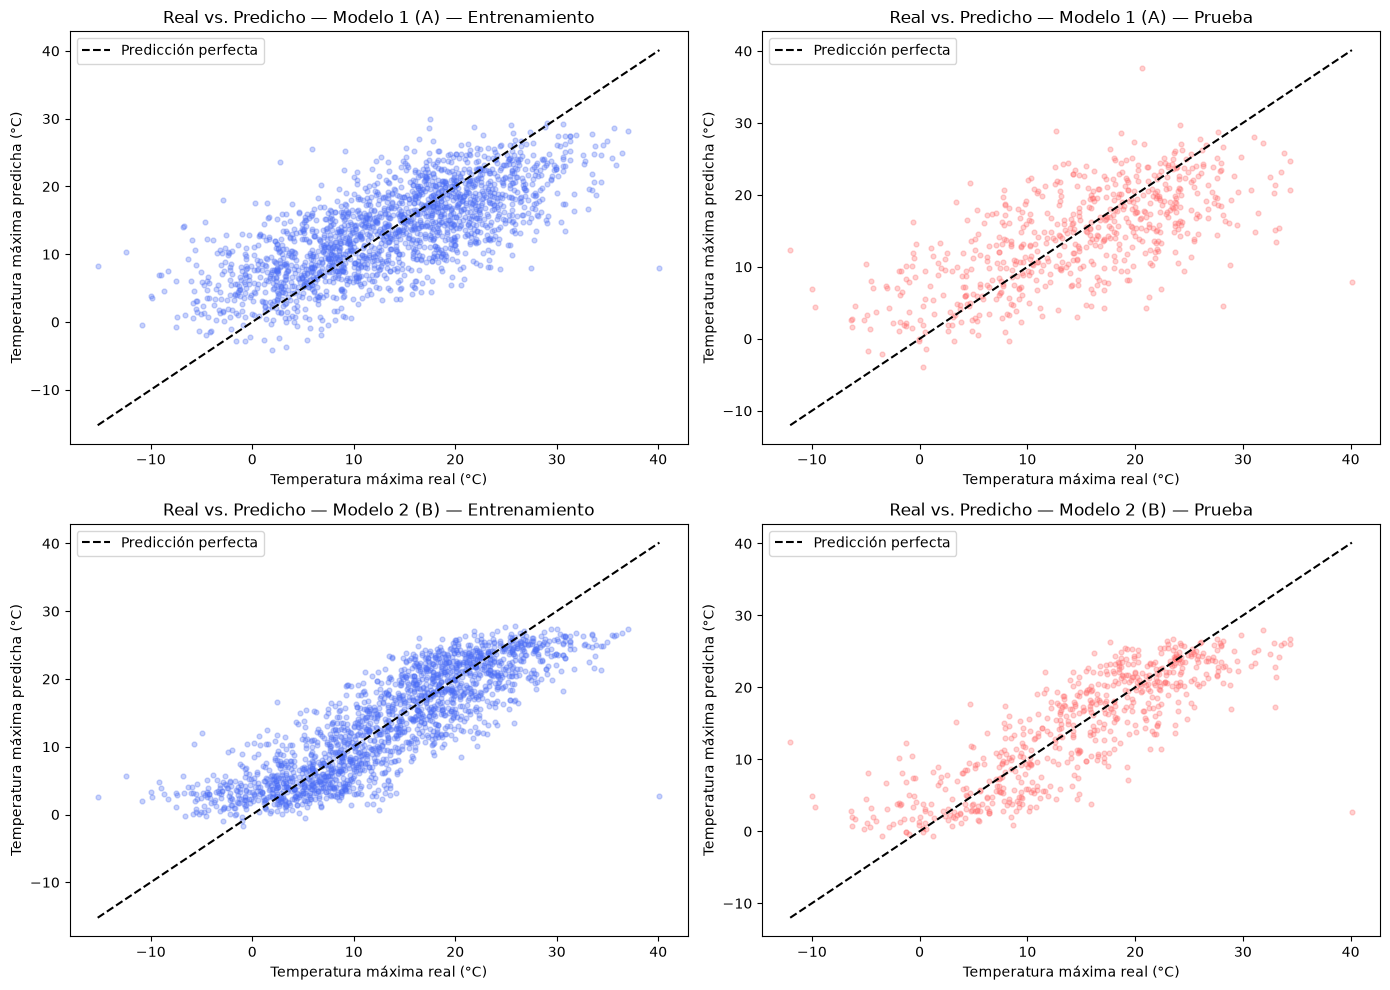

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

paneles = [
    (axes[0, 0], y_train, y_train_pred_1, "Modelo 1 (A) — Entrenamiento", "#4C6EF5"),
    (axes[0, 1], y_test,  y_test_pred_1,  "Modelo 1 (A) — Prueba",        "#FF6B6B"),
    (axes[1, 0], y_train, y_train_pred_2, "Modelo 2 (B) — Entrenamiento", "#4C6EF5"),
    (axes[1, 1], y_test,  y_test_pred_2,  "Modelo 2 (B) — Prueba",        "#FF6B6B"),
]

for ax, y_real, y_pred, titulo, color in paneles:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.3, color=color, s=12)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1.5, label="Predicción perfecta")
    ax.set_xlabel("Temperatura máxima real (°C)")
    ax.set_ylabel("Temperatura máxima predicha (°C)")
    ax.set_title(f"Real vs. Predicho — {titulo}")
    ax.legend()

plt.tight_layout()
plt.show()

### 6.3 Selección del mejor modelo (justificación)

**Criterio de selección.** Como se definió en la sección 5.3, la métrica base para decidir entre los dos modelos es el **RMSE sobre el conjunto de prueba (test)**, no sobre entrenamiento. Esto es intencional: el objetivo de un modelo de regresión no es ajustarse bien a los datos que ya vio, sino predecir correctamente sobre datos nuevos, que es justamente lo que simula el conjunto de test.

**Lo que muestran las métricas.** El Modelo 2 (estrategia B) supera al Modelo 1 en los dos conjuntos y en las tres métricas. En prueba, su RMSE es de 4.93 °C frente a 6.76 °C del Modelo 1, su MAE de 3.74 °C frente a 5.25 °C, y su R² de 0.70 frente a 0.43. Ninguno de los dos muestra sobreajuste severo: la diferencia de RMSE entre train y test es de +0.28 °C en el Modelo 2 y de +0.48 °C en el Modelo 1, ambas pequeñas frente a la magnitud del error. La ligera ventaja del Modelo 2 en esa diferencia es coherente con su menor número de parámetros.

**Por qué el Modelo 2 es mejor (diagnóstico).** La ventaja no proviene de disponer de más información, sino de representarla de forma que un modelo lineal pueda usarla. Los tres factores principales son:

1. *Codificación cíclica del día del año.* `dia_sin` y `dia_cos` permiten al modelo representar el ciclo estacional como una onda. El Modelo 1 recibe la misma información en `dia_del_anio`, pero en forma cruda solo puede ajustarle una recta, lo que carece de sentido para una variable que se repite cada año.
2. *Selección de variables con fundamento físico.* Los indicadores de presión y humedad tienen una relación directa y bien documentada con la temperatura del día siguiente (Ahrens & Henson, 2019). El Modelo 1, al usar las 22 variables numéricas y las 3 categóricas —que tras el `OneHotEncoder` se expanden a 95 columnas—, incorpora además categorías poco frecuentes de `estacion_anio` y `sector_viento` que generan columnas binarias con muy pocas observaciones, sobre las que el modelo ajusta coeficientes poco fiables (Kuhn & Johnson, 2013).
3. *Corrección de escala en la humedad.* `humedad_media`, `humedad_min` y `humedad_max` mezclaban fracción y porcentaje en la misma columna; unificarlas antes del escalado permite que el `StandardScaler` produzca una variable coherente.

**El papel de la limpieza de la variable objetivo.** Conviene señalar el efecto de la corrección aplicada en la sección 4: antes de descartar los cuatro registros con `temp_max_manana` físicamente imposible (hasta 63.05 °C), el Modelo 1 alcanzaba un RMSE en test de 31.77 °C y un R² de -10.70, es decir, predecía peor que responder siempre el promedio. Bastaron **dos etiquetas erróneas en el conjunto de entrenamiento** para desestabilizar por completo un modelo de 95 parámetros. El Modelo 2, con 11 columnas, era mucho menos sensible a ese mismo problema (RMSE test de 5.25 °C antes de la corrección). Es una ilustración directa de por qué la calidad de la variable objetivo es crítica y de por qué los modelos con muchos parámetros son más frágiles ante datos erróneos.

**Evidencia visual.** Esto se confirma en los gráficos de dispersión de la sección 6.2: en ambos modelos los puntos se agrupan alrededor de la línea de predicción perfecta, pero la nube del Modelo 2 es visiblemente más estrecha, tanto en entrenamiento como en prueba.

**Decisión final.** Por lo anterior, se selecciona el **Modelo 2 (estrategia B)** como el modelo final. Explica cerca del 70 % de la variabilidad de la temperatura máxima del día siguiente sobre datos no vistos, con un error típico de 4.93 °C, y lo hace con 11 variables de interpretación física clara.

## 7. Evaluación cualitativa e interpretación

*Se interpretó el mejor modelo y se revisaron sus supuestos cualitativamente.*

### 7.1 Coeficientes del mejor modelo

*La regresión lineal modela la relación entre la variable objetivo `temp_max_manana` y las variables predictoras mediante una combinación lineal:*

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_m x_m$$

*donde $\beta_0$ es el **intercepto** (valor de $\hat{y}$ cuando todas las $x_i = 0$, es decir, cuando todas las variables numéricas están en su media, ya que fueron estandarizadas) y $\beta_1, \ldots, \beta_m$ son los **coeficientes**: cuánto cambia $\hat{y}$ cuando $x_i$ aumenta en una unidad, manteniendo las demás fijas. Como las variables numéricas pasaron por `StandardScaler`, una unidad equivale a una desviación estándar de esa variable.*

In [55]:
# El mejor modelo se selecciona por el menor RMSE sobre el conjunto de prueba (métrica base).
if rmse_test_2 < rmse_test_1:
    mejor_nombre = "Modelo 2 (estrategia B)"
    mejor_modelo = modelo_2
    mejor_features = feature_names_b
    y_test_pred_mejor = y_test_pred_2
else:
    mejor_nombre = "Modelo 1 (estrategia A)"
    mejor_modelo = modelo_1
    mejor_features = feature_names
    y_test_pred_mejor = y_test_pred_1

print(f"Mejor modelo según RMSE en test: {mejor_nombre}")

Mejor modelo según RMSE en test: Modelo 2 (estrategia B)


In [56]:
print(f"Modelo interpretado: {mejor_nombre}")
print(f"Intercepto (β₀): {mejor_modelo.intercept_:.4f} °C")
print(f"Número de coeficientes: {len(mejor_modelo.coef_)}")

nombres_limpios = [n.replace("num__", "").replace("cat__", "") for n in mejor_features]

coeficientes = pd.DataFrame({
    "Variable": nombres_limpios,
    "Coeficiente": mejor_modelo.coef_,
})

display(coeficientes)

Modelo interpretado: Modelo 2 (estrategia B)
Intercepto (β₀): 13.4667 °C
Número de coeficientes: 11


,Variable,Coeficiente
0,presion_media,0.245639
1,presion_min,-0.276340
2,presion_max,0.299464
3,presion_desv,-0.335960
4,humedad_media,-0.437762
5,humedad_min,-0.534406
6,humedad_max,-0.367064
7,humedad_desv,1.652447
8,dia_sin,-2.161934
9,dia_cos,-5.803069


### 7.2 Tabla de importancia de variables

*Se organizaron los coeficientes en una tabla de importancia. Como todas las variables numéricas fueron estandarizadas y las categóricas codificadas en variables binarias, la magnitud absoluta del coeficiente es comparable entre variables y sirve como medida de importancia dentro del modelo lineal. El signo indica la dirección del efecto sobre la temperatura máxima del día siguiente.*

In [57]:
importancia = (
    coeficientes
    .assign(Importancia=coeficientes["Coeficiente"].abs())
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)
importancia["Efecto"] = np.where(importancia["Coeficiente"] >= 0, "Positivo", "Negativo")

print("Top 15 variables por importancia (|coeficiente|):")
display(importancia.head(15))

Top 15 variables por importancia (|coeficiente|):


,Variable,Coeficiente,Importancia,Efecto
0,dia_cos,-5.803069,5.803069,Negativo
1,dia_sin,-2.161934,2.161934,Negativo
2,humedad_desv,1.652447,1.652447,Positivo
3,humedad_min,-0.534406,0.534406,Negativo
4,humedad_media,-0.437762,0.437762,Negativo
5,humedad_max,-0.367064,0.367064,Negativo
6,presion_desv,-0.335960,0.335960,Negativo
7,viento_este,-0.308081,0.308081,Negativo
8,presion_max,0.299464,0.299464,Positivo
9,presion_min,-0.276340,0.276340,Negativo


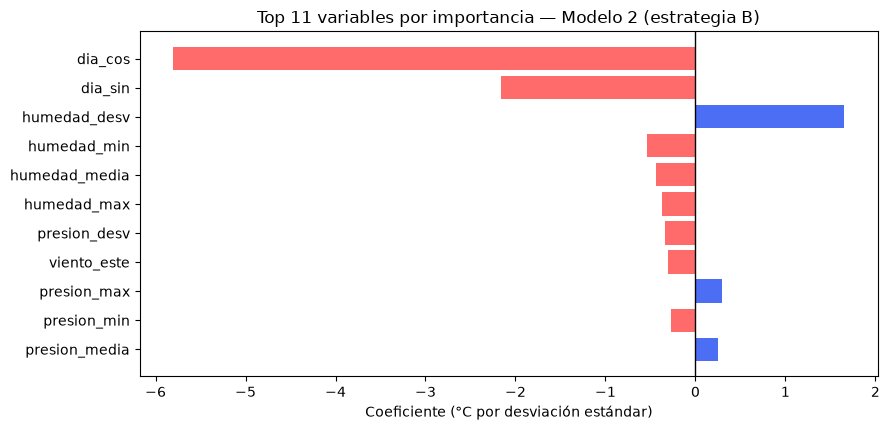

In [58]:
top_n = min(15, len(importancia))
top_vars = importancia.head(top_n).iloc[::-1]

plt.figure(figsize=(9, max(4, 0.4 * top_n)))
colores = np.where(top_vars["Coeficiente"] >= 0, "#4C6EF5", "#FF6B6B")
plt.barh(top_vars["Variable"], top_vars["Coeficiente"], color=colores)
plt.axvline(0, color="black", lw=1)
plt.xlabel("Coeficiente (°C por desviación estándar)")
plt.title(f"Top {top_n} variables por importancia — {mejor_nombre}")
plt.tight_layout()
plt.show()

### 7.3 Validación de los supuestos de la regresión lineal

*Se revisaron los cuatro supuestos clásicos de la regresión lineal sobre los residuales del conjunto de prueba ($e_i = y_i - \hat{y}_i$):*

| Supuesto | Qué significa | Cómo se revisa |
|---|---|---|
| **Linealidad** | La relación entre predictoras y objetivo es lineal | Residuales vs. valores predichos: deben dispersarse sin patrón alrededor de 0 |
| **Independencia** | Los residuales no están correlacionados entre sí | Residuales en el orden de los datos; estadístico de Durbin-Watson (≈ 2 indica independencia) |
| **Homocedasticidad** | La varianza del error es constante | Residuales vs. predichos: la dispersión debe ser pareja, sin forma de embudo |
| **Normalidad** | Los residuales se distribuyen normalmente | Histograma y gráfico Q-Q de los residuales |

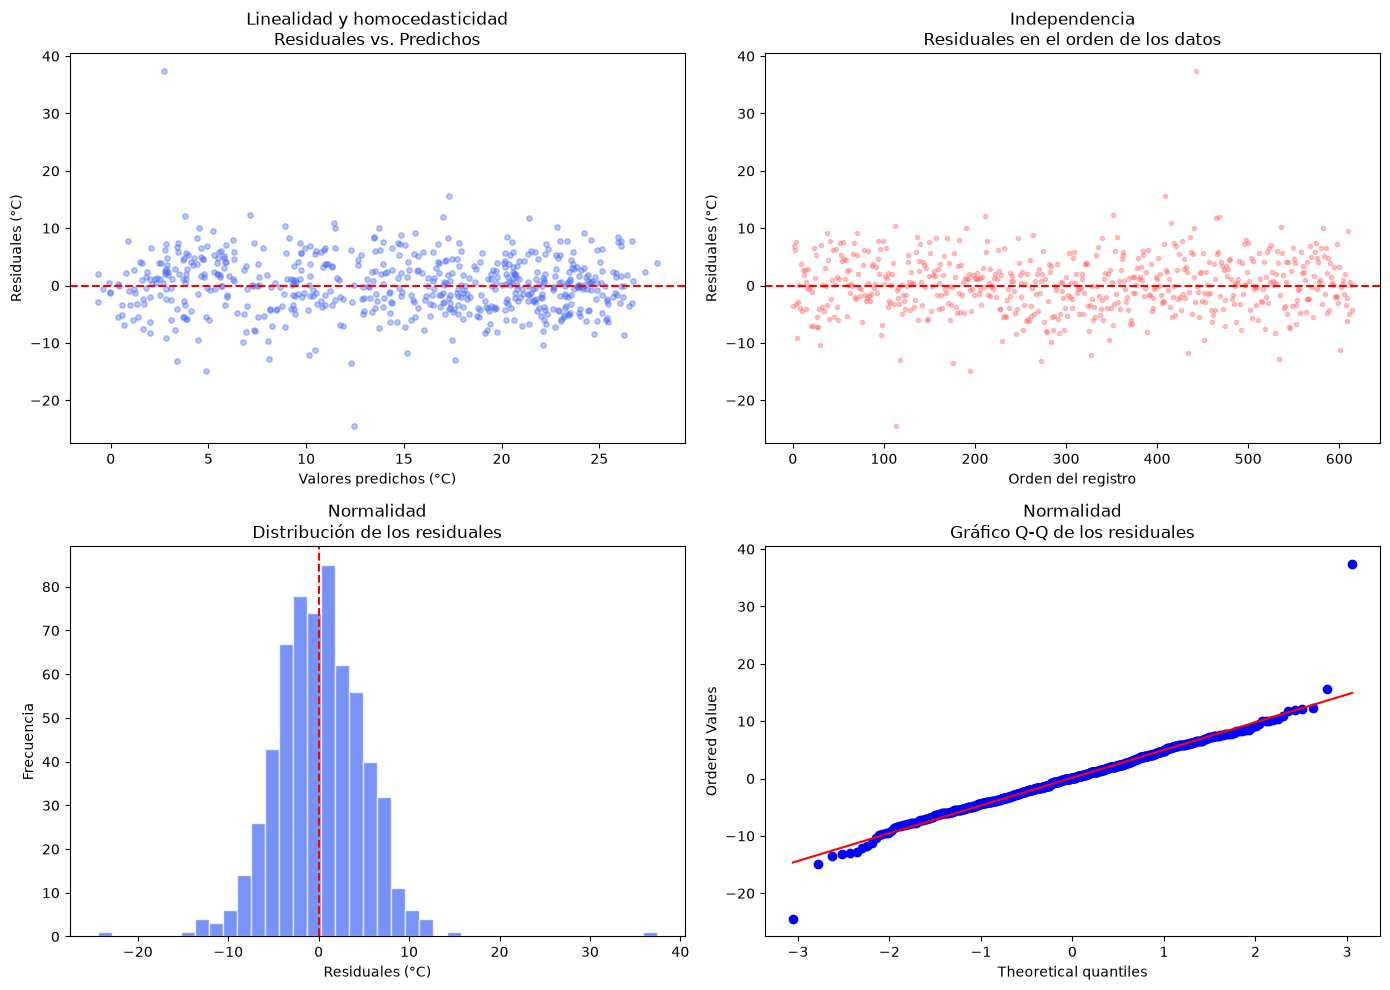

In [59]:
from scipy import stats

residuales = y_test - y_test_pred_mejor

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Linealidad y homocedasticidad: residuales vs. valores predichos
axes[0, 0].scatter(y_test_pred_mejor, residuales, alpha=0.4, color="#4C6EF5", s=15)
axes[0, 0].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0, 0].set_xlabel("Valores predichos (°C)")
axes[0, 0].set_ylabel("Residuales (°C)")
axes[0, 0].set_title("Linealidad y homocedasticidad\nResiduales vs. Predichos")

# 2. Independencia: residuales en el orden de los registros
axes[0, 1].plot(range(len(residuales)), residuales, marker="o", linestyle="", alpha=0.4,
                color="#FF6B6B", markersize=3)
axes[0, 1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0, 1].set_xlabel("Orden del registro")
axes[0, 1].set_ylabel("Residuales (°C)")
axes[0, 1].set_title("Independencia\nResiduales en el orden de los datos")

# 3. Normalidad: histograma de los residuales
axes[1, 0].hist(residuales, bins=40, color="#4C6EF5", alpha=0.75, edgecolor="white")
axes[1, 0].axvline(0, color="red", linestyle="--", lw=1.5)
axes[1, 0].set_xlabel("Residuales (°C)")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_title("Normalidad\nDistribución de los residuales")

# 4. Normalidad: gráfico Q-Q
stats.probplot(residuales, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Normalidad\nGráfico Q-Q de los residuales")

plt.tight_layout()
plt.show()

In [60]:
# Estadísticos de apoyo para la revisión de los supuestos
media_residuales = residuales.mean()
durbin_watson = np.sum(np.diff(residuales.values) ** 2) / np.sum(residuales.values ** 2)
shapiro_stat, shapiro_p = stats.shapiro(residuales)

print(f"Media de los residuales            : {media_residuales:.4f} °C  (idealmente ≈ 0)")
print(f"Desviación estándar de residuales  : {residuales.std():.4f} °C")
print(f"Durbin-Watson (independencia)      : {durbin_watson:.4f}  (≈ 2 indica ausencia de autocorrelación)")
print(f"Shapiro-Wilk (normalidad) — estad. : {shapiro_stat:.4f}, p-valor: {shapiro_p:.4e}")

Media de los residuales            : 0.1366 °C  (idealmente ≈ 0)
Desviación estándar de residuales  : 4.9316 °C
Durbin-Watson (independencia)      : 2.0096  (≈ 2 indica ausencia de autocorrelación)
Shapiro-Wilk (normalidad) — estad. : 0.9609, p-valor: 9.8925e-12


## 8. Análisis de resultados

*Se respondieron las preguntas con evidencia obtenida del análisis, sin inventar resultados.*

### 8.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

*Se respondió con los valores calculados y su interpretación.*

**Respuesta:**

### 8.2 A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre test? ¿Qué interpretación tienen las métricas?

*Se respondió comparando RMSE, MAE y R², e interpretando sus magnitudes.*

**Respuesta:**

### 8.3 ¿Cuáles variables fueron seleccionadas? ¿Qué interpretación tienen frente al problema y cómo apoyan la toma de decisiones?

*Se describieron las variables seleccionadas, su interpretación y utilidad para decidir.*

**Respuesta:**

### 8.4 ¿Cómo se representa matemáticamente la regresión lineal en este contexto? Método utilizado y proceso de solución.

*Se explicó la representación matemática, el método utilizado y el proceso de solución.*

**Respuesta:**

### 8.5 ¿Qué tipos de sesgo podrían afectar los resultados? Describir dos.

*Se describieron dos sesgos posibles y cómo podrían afectar las conclusiones.*

**Respuesta:**

## 9. Uso del modelo: predicciones sobre datos no etiquetados

*Se aplicó el mejor modelo al archivo de test no etiquetado y se documentó la salida.*

### 9.1 Aplicación del mejor modelo al archivo de test

*Se generaron predicciones para el archivo de test no etiquetado.*

In [61]:
# TODO: aplicar el mejor modelo al archivo de test.


### 9.2 Exportación de resultados a "Datos test Lab1.csv"

*Se exportaron las predicciones al archivo "Datos test Lab1.csv".*

In [62]:
# TODO: exportar resultados a "Datos test Lab1.csv".


## 10. Conclusiones

*Se resumieron los resultados, las decisiones, las limitaciones y los aprendizajes del laboratorio.*

**Conclusiones:**

## 11. Uso de herramientas de IA generativa

*Se declaró y analizó críticamente el uso de herramientas de IA generativa.*

### 11.1 Declaración del uso (herramienta y tipo de uso)

*Se indicó qué herramienta se usó y para qué tipo de apoyo.*

**Respuesta:**

### 11.2 Prompts utilizados

*Se registraron los prompts utilizados durante el trabajo.*

**Prompts:**

### 11.3 Análisis crítico del resultado (responder al menos dos de las preguntas guía del curso)

*Se respondieron al menos dos preguntas guía y se evaluó críticamente el resultado de la IA.*

**Respuesta:**

### 11.4 Aportes propios de los estudiantes

*Se describieron los aportes, las decisiones y las verificaciones realizadas por los estudiantes.*

**Aportes:**

## 12. Referencias

*Se registraron las fuentes de datos, la documentación y la bibliografía utilizadas.*

**Referencias:**

- Ahrens, C. D., & Henson, R. (2019). *Meteorology Today: An Introduction to Weather, Climate, and the Environment* (12.ª ed.). Cengage Learning.
- Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling*. Springer.